In [1]:
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_core.output_parsers import StrOutputParser

In [2]:
llm = ChatOllama(
    model='llama3.2:latest'
)

In [3]:
parser = StrOutputParser()

In [4]:
chain = llm | parser

In [5]:
result = chain.invoke("hello")

In [6]:
result

'Hello! How can I assist you today?'

In [7]:
class LLMState(TypedDict):

    question : str 
    answer : str 

In [8]:
def printer(state : LLMState) -> LLMState: 

    question = state['question']

    answer = chain.invoke(question)

    state['answer'] = answer

    return state

In [9]:
graph = StateGraph(LLMState)

graph.add_node('printer',printer)

graph.add_edge(START,'printer')
graph.add_edge('printer',END)

workflow = graph.compile()

In [10]:
result = workflow.invoke({'question':"Explain about Artificial Intelligence"})

In [15]:
for message_chunk, metadata in workflow.stream({'question':"Explain about Artificial Intelligence"},stream_mode="messages"):
    if message_chunk.content:
        print(message_chunk.content, end=" ", flush=True)

Art ificial  Intelligence  ( AI )  is  a  branch  of  computer  science  that  focuses  on  creating  intelligent  machines  that  can  think ,  learn ,  and  act  like  humans .  AI  involves  developing  algorithms ,  software ,  and  hardware  to  enable  computers  to  perform  tasks  that  typically  require  human  intelligence ,  such  as :

 1 .  ** Reason ing **:  Making  decisions  based  on  available  data .
 2 .  ** Learning **:  Impro ving  performance  over  time  through  experience  or  training .
 3 .  ** Problem -solving **:  Ident ifying  solutions  to  complex  problems .
 4 .  ** Per ception **:  Inter pre ting  and  understanding  sensory  data  from  the  environment .

 There  are  several  types  of  AI ,  including :

 1 .  ** N arrow  or  Weak  AI **:  Designed  to  perform  a  specific  task ,  such  as  image  recognition  or  language  translation .
 2 .  ** General  or  Strong  AI **:  A ims  to  create  intelligent  machines  that  can  perform  any  in

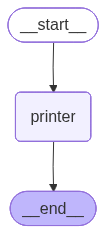

In [23]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [16]:
import uuid

def generate_thread_id():
    thread_id = uuid.uuid4()
    return thread_id

In [17]:
res = generate_thread_id()
res

UUID('b20d8e2c-9070-43d0-86a8-c3a25cc364c7')